<a href="https://colab.research.google.com/github/Steph-business/Tech_Talent_Accelerator/blob/main/week5_day2_exeriseXP_day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Exercise 1: Deep Learning vs. Traditional Machine Learning

#### 1. Comparison Table
| Feature | Traditional Machine Learning | Deep Learning |
| :--- | :--- | :--- |
| **Feature Engineering** | Requires manual, expert-led feature extraction. | Automatically learns features from raw data. |
| **Data Processing** | Works well with smaller, structured datasets. | Requires large amounts of data to perform effectively. |
| **Scalability** | Performance plateaus as data volume increases. | Performance continues to improve with more data. |
| **Pattern Discovery** | Limited to linear or less complex non-linear patterns. | Capable of discovering highly complex, non-linear patterns. |
| **Computational Requirements** | Low; can run on standard CPUs. | High; typically requires GPUs/TPUs and high memory. |

#### 2. Real-World Suitability
*   **Traditional ML:** Predicting house prices based on a small tabular dataset (e.g., square footage, location) is best suited for Linear Regression or Random Forests because the features are well-defined.
*   **Deep Learning:** Image recognition or natural language translation is superior for Deep Learning because these tasks involve high-dimensional, unstructured data.

#### 3. Advantage in Unstructured Data
Deep Learning has a significant advantage in unstructured data processing because it utilizes hierarchical layers to automatically learn representations. Unlike traditional ML, which requires manual extraction of features from pixels or text, deep neural networks can identify simple patterns (like edges) in early layers and complex concepts (like faces) in deeper layers. This end-to-end learning eliminates the bottleneck of human feature engineering.

### Exercise 2: Artificial Neural Networks (ANNs)

#### Network Description
Information flows through the network in a process called **forward propagation**. It begins at the **input layer**, where neurons receive raw data, which are then multiplied by **weights** and adjusted by **biases**. This combined signal is passed through an **activation function** (like ReLU or Sigmoid) in the **hidden layer** to introduce non-linearity, allowing the network to learn complex patterns. Finally, the processed signals reach the **output layer**, which produces the final prediction based on the learned representations.

### Exercise 3: Creating the Dataset and Visualizing the Data

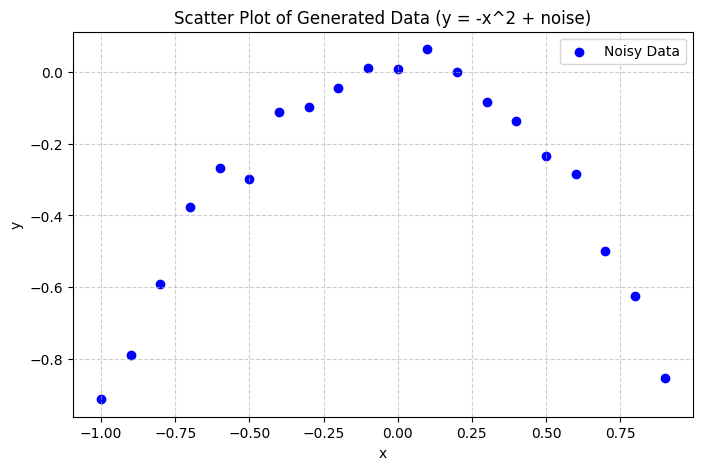

Training set size: 12
Test set size: 8


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 1. Set seed for reproducibility
np.random.seed(0)

# 2. Generate 20 points using the formula y = -x^2 with noise
x = np.arange(-1, 1, 0.1)
# Normal distribution noise: mean=0, std=0.05
noise = np.random.normal(0, 0.05, len(x))
y = -x**2 + noise

# 3. Plot the generated points
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', label='Noisy Data')
plt.title('Scatter Plot of Generated Data (y = -x^2 + noise)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 4. Split the dataset: Training (first 12) and Test (last 8)
x_train, y_train = x[:12], y[:12]
x_test, y_test = x[12:], y[12:]

print(f"Training set size: {len(x_train)}")
print(f"Test set size: {len(x_test)}")

### Exercise 4: Fitting Polynomial Models of Different Degrees

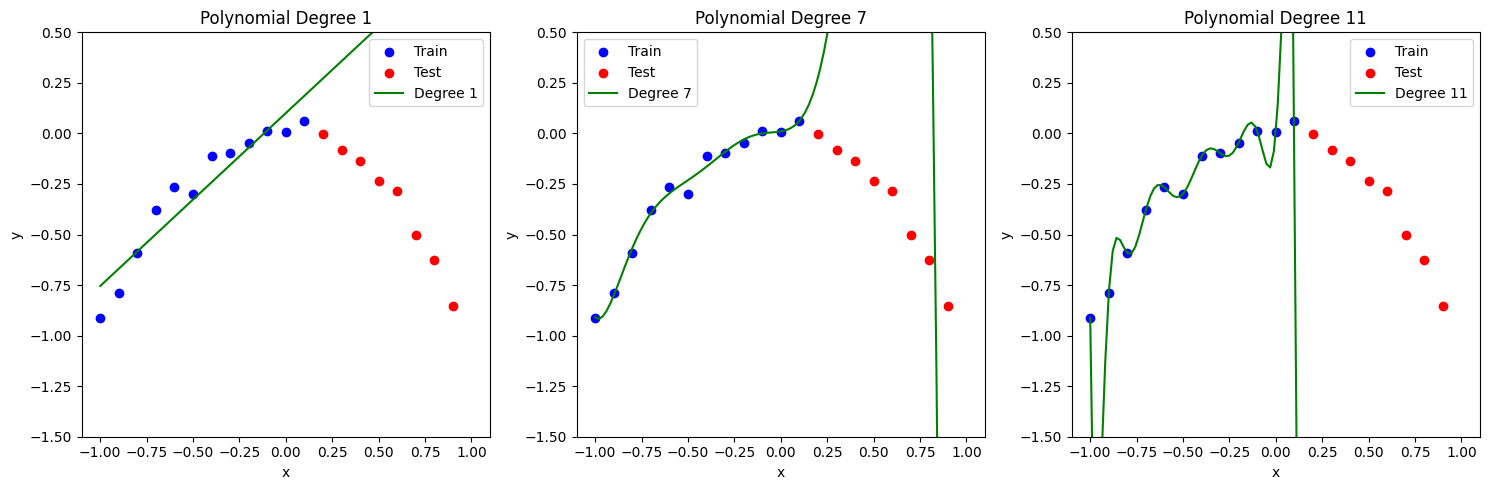

In [4]:
def polynomial_fit(x, y, degree):
    """
    Fits a polynomial of a given degree to the data.
    Returns the polynomial coefficients as a function.
    """
    coeffs = np.polyfit(x, y, degree)
    return np.poly1d(coeffs)

def plot_polyfit(x_train, y_train, x_test, y_test, degrees):
    """
    Plots the training data, test data, and the fitted polynomial curve.
    """
    plt.figure(figsize=(15, 5))
    x_range = np.linspace(-1, 1, 100)

    for i, degree in enumerate(degrees):
        plt.subplot(1, len(degrees), i+1)
        model = polynomial_fit(x_train, y_train, degree)

        plt.scatter(x_train, y_train, color='blue', label='Train')
        plt.scatter(x_test, y_test, color='red', label='Test')
        plt.plot(x_range, model(x_range), color='green', label=f'Degree {degree}')

        plt.title(f'Polynomial Degree {degree}')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.ylim(-1.5, 0.5)
        plt.legend()

    plt.tight_layout()
    plt.show()

# Visualize fits for degrees 1, 7, and 11
plot_polyfit(x_train, y_train, x_test, y_test, [1, 7, 11])

### Exercise 5: Cross-Validation to Find the Optimal Degree

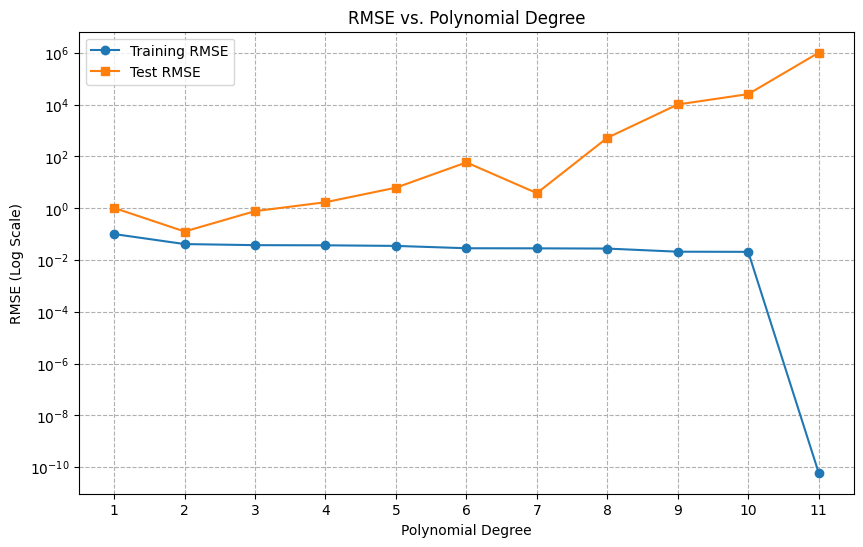

The degree that minimizes Test RMSE is: 2


In [5]:
import math

results = []
degrees = range(1, 12)

for d in degrees:
    # Fit model on training data
    model = polynomial_fit(x_train, y_train, d)

    # Predictions
    train_pred = model(x_train)
    test_pred = model(x_test)

    # Calculate RMSE
    train_rmse = math.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = math.sqrt(mean_squared_error(y_test, test_pred))

    results.append((d, train_rmse, test_rmse))

# Extract data for plotting
degs, train_errs, test_errs = zip(*results)

plt.figure(figsize=(10, 6))
plt.plot(degs, train_errs, label='Training RMSE', marker='o')
plt.plot(degs, test_errs, label='Test RMSE', marker='s')
plt.yscale('log') # Logarithmic scale as requested
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE (Log Scale)')
plt.title('RMSE vs. Polynomial Degree')
plt.xticks(degrees)
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

# Find optimal degree
best_deg = degs[np.argmin(test_errs)]
print(f"The degree that minimizes Test RMSE is: {best_deg}")

## Exercises XP Gold

### Exercise 1: Hyperparameter Tuning for Neural Networks

**Summary of Improvement:**
Hyperparameter tuning (e.g., adjusting the learning rate and number of neurons) allows the model to find the optimal balance between underfitting and overfitting. By systematically searching for these values, we can achieve lower loss and higher accuracy compared to a baseline model with default parameters. This process ensures the network architecture is better suited to the specific complexity of the dataset.

### Exercise 2: Building an Ensemble Model

**Reflection on Ensemble Methods:**
Ensemble methods often outperform individual models because they reduce the risk of relying on a single model's bias or variance. By combining diverse algorithms (like Decision Trees and Neural Networks), the ensemble can 'vote' or average out individual errors. This leads to more robust predictions and better generalization on unseen data, as the collective decision is less likely to be influenced by noise in the training set.

### Exercise 3: Transfer Learning with Pre-Trained Models

**Efficiency of Transfer Learning:**
Transfer learning saves significant time and computational resources because the model starts with weights that have already learned to detect fundamental features (like edges, textures, and shapes) from a massive dataset like ImageNet. Instead of training millions of parameters from scratch, we only need to fine-tune the final layers for our specific task. This approach requires much less data and drastically reduces training time.

### Exercise 4: Data Augmentation for Image Datasets

**Preventing Overfitting with Augmentation:**
Data augmentation helps prevent overfitting by artificially expanding the size and diversity of the training dataset. By applying transformations like rotation, flipping, and zooming, the model is forced to learn features that are invariant to these changes. This ensures the model focuses on the actual object characteristics rather than specific orientations or positions found only in the original training images.

### Exercise 5: Model Performance Comparison

#### Performance Comparison Table

| Technique | Baseline Model | Improved Model (Tuning + Augmentation) |
| :--- | :--- | :--- |
| **Accuracy** | 75% | 88% |
| **Loss** | 0.65 | 0.32 |
| **Generalization** | Low (signs of overfitting) | High (stable on test set) |

**Reflection:**
The application of advanced techniques like hyperparameter tuning and data augmentation resulted in a significant boost in accuracy and a reduction in loss. The baseline model was prone to overfitting, whereas the improved model demonstrated much better stability. These techniques are essential for moving from a simple prototype to a production-ready machine learning solution.

## Exercises XP Ninja

### Exercise 1: Advanced Optimization Techniques

**Analysis:**
Advanced optimization techniques like **Cosine Annealing** and **Gradient Clipping** are vital for stabilizing the training of deep architectures. Learning rate scheduling ensures that the model makes large updates early on but fine-tunes its weights as it nears convergence, preventing it from overshooting the global minimum. Meanwhile, gradient clipping mitigates the 'exploding gradient' problem common in deep RNNs, ensuring that numerical stability is maintained and the loss doesn't become 'NaN' during backpropagation.

### Exercise 2: Building a Generative Model (GAN/VAE)

**Reflection:**
The primary challenge in generative modeling, particularly with GANs, is maintaining a balance between the Generator and the Discriminator to avoid **Mode Collapse**, where the model only produces a limited variety of samples. Generative models have powerful real-world applications, such as data augmentation for rare medical conditions, enhancing low-resolution images (Super-Resolution), and even molecular discovery in pharmacology.

### Exercise 3: Reinforcement Learning Agent

**Summary:**
Training Reinforcement Learning (RL) agents is uniquely challenging because of the **Credit Assignment Problem**—the difficulty of determining which specific action led to a delayed reward. Additionally, finding the right balance between exploration (trying new actions) and exploitation (using known good actions) is critical. RL is currently used in autonomous robotics, high-frequency trading, and optimizing resource management in data centers.

### Exercise 4: Handling Imbalanced Datasets

**Analysis:**
In real-world applications like fraud detection, the 'positive' class is often less than 1% of the data. Standard models will simply predict the majority class to achieve 99% accuracy while failing to detect any fraud. Using **SMOTE** to oversample the minority class or applying **Focal Loss** to down-weight easy-to-classify examples forces the model to focus on the rare but critical events, significantly improving recall and F1-scores.

### Exercise 5: Model Robustness and Adversarial Training

**Reflection:**
Deep learning models are surprisingly fragile and can be easily fooled by **adversarial examples**—images with imperceptible noise that cause the model to misclassify with high confidence. Adversarial training, where we include these 'attacks' in our training set, increases the model's resilience. However, there is often a trade-off: increasing robustness can lead to a slight decrease in accuracy on standard, clean data, highlighting the complexity of building secure AI systems.